In [ ]:
# === Step 1: Prepare the working environment ===
print("1. Setting up the working environment...")
!pip install kaggle -q

from google.colab import files
import os

# Upload kaggle.json file if it doesn't exist
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print('Please upload the kaggle.json file you downloaded from your Kaggle account')
    files.upload()
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

# Download and extract the dataset
DATASET_DIR = "fire_dataset"
if not os.path.exists(DATASET_DIR):
    print("\n2. Downloading and extracting data...")
    # Link: https://www.kaggle.com/datasets/phylake1337/fire-dataset
    !kaggle datasets download -d phylake1337/fire-dataset -q && unzip -q fire-dataset.zip
else:
    print("\n2. Data already exists.")

print("\nEnvironment and data prepared successfully!")

1. Setting up the working environment...
Please upload the kaggle.json file you downloaded from your Kaggle account


Saving kaggle.json to kaggle.json

2. Downloading and extracting data...
Dataset URL: https://www.kaggle.com/datasets/phylake1337/fire-dataset
License(s): CC0-1.0

Environment and data prepared successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, applications, callbacks
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns


IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# === Step 3: Efficiently load and prepare data ===
print("\n3. Loading and preparing data...")

# Load the full dataset
full_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)
class_names = full_ds.class_names
print(f"Found the following classes: {class_names}")

# Function to apply preprocessing and optimize performance
def prepare(ds):
    # Apply MobileNetV2 specific preprocessing
    ds = ds.map(lambda x, y: (applications.mobilenet_v2.preprocess_input(x), y), num_parallel_calls=AUTOTUNE)
    # Cache and prefetch for faster performance
    ds = ds.cache().prefetch(buffer_size=AUTOTUNE)
    return ds

# Split data into training, validation, and test (70%, 15%, 15%)
DATASET_SIZE = len(full_ds)
train_size = int(0.7 * DATASET_SIZE)
val_size = int(0.15 * DATASET_SIZE)
test_size = DATASET_SIZE - train_size - val_size

train_ds = full_ds.take(train_size)
val_ds = full_ds.skip(train_size).take(val_size)
test_ds = full_ds.skip(train_size + val_size).take(test_size)

# Apply the prepare function to each dataset split
train_ds = prepare(train_ds)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

print(f"Data split into: {len(train_ds)} training batches, {len(val_ds)} validation batches, {len(test_ds)} test batches.")


3. Loading and preparing data...
Found 999 files belonging to 2 classes.
Found the following classes: ['fire_images', 'non_fire_images']
Data split into: 22 training batches, 4 validation batches, 6 test batches.


Displaying 16 random images from the training data...


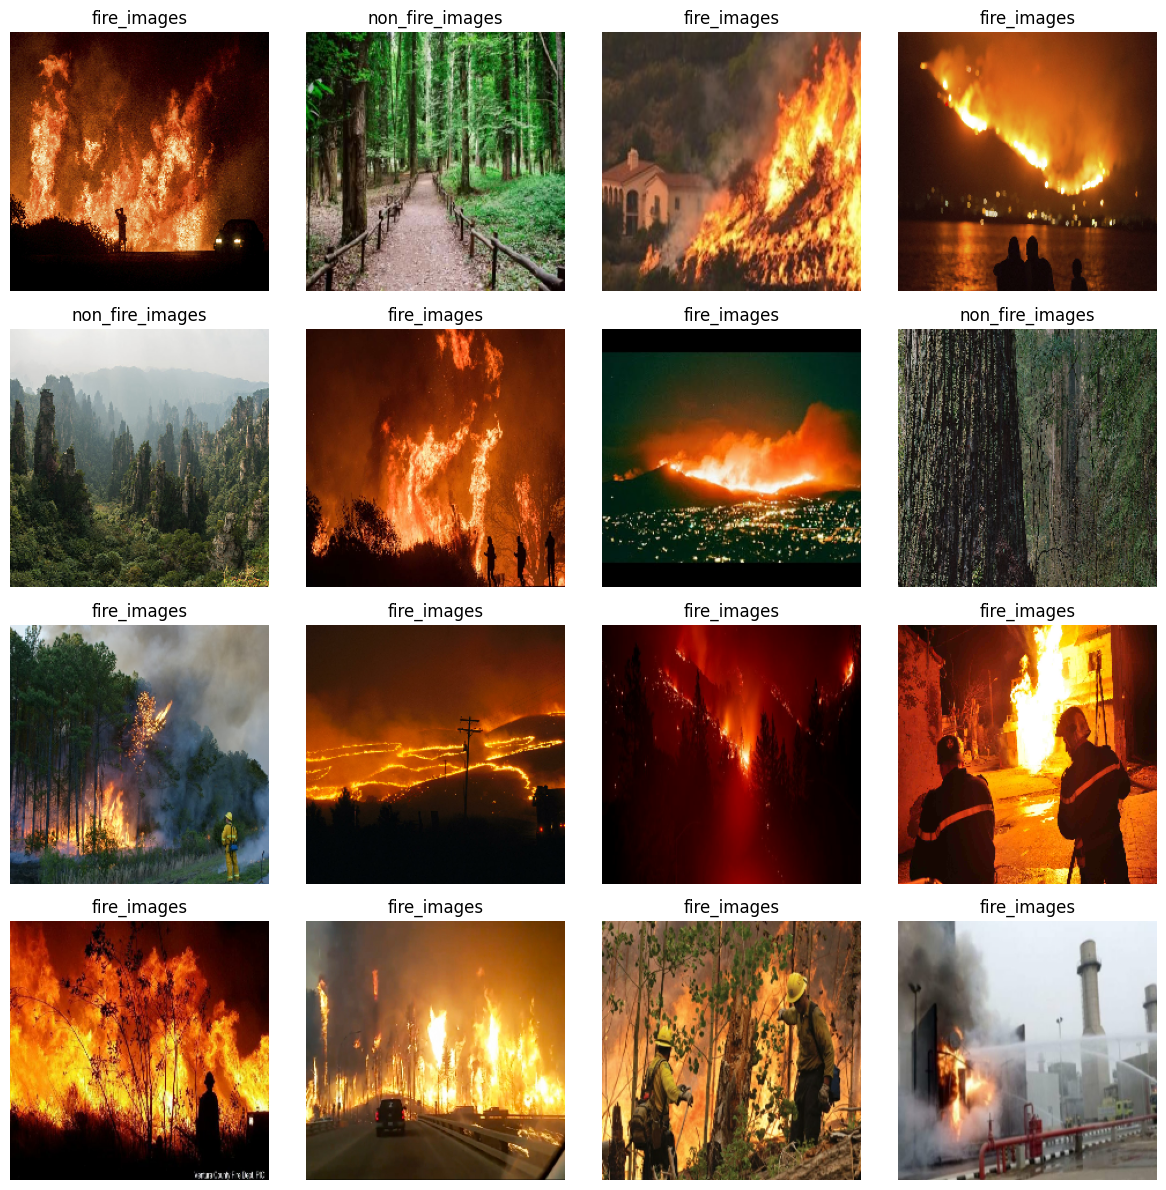

In [ ]:
# === Step 8: Display sample training data ===
print("Displaying 16 random images from the training data...")

plt.figure(figsize=(12, 12))

# Take one batch from the training set to display
for images, labels in train_ds.take(1):
    for i in range(16):
        # Create a subplot for each image
        ax = plt.subplot(4, 4, i + 1)

        # Reverse the preprocessing to display the image correctly
        # MobileNetV2 preprocess_input converts pixels to the range [-1, 1]
        # So we return it to the range [0, 1] for display
        img_display = (images[i].numpy() + 1) / 2.0

        plt.imshow(img_display)

        # Get the class name from the one-hot array
        class_index = np.argmax(labels[i])
        plt.title(class_names[class_index])

        # Hide axes
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# === Step 4: Build the Model (using Sequential API for clarity) ===
print("\n4. Building the model...")

def create_model():
    # Load the base model and freeze its weights
    base_model = applications.MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )
    base_model.trainable = False

    # Build the final model sequentially
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = create_model()
model.summary()


4. Building the model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# === Step 5: Train the Model ===
print("\n5. Training the model...")

# Set up callbacks for saving the best model and early stopping
checkpoint_cb = callbacks.ModelCheckpoint("fire_model.weights.h5", save_best_only=True, save_weights_only=True, monitor="val_accuracy")
early_stopping_cb = callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_loss")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stopping_cb, checkpoint_cb]
)


5. Training the model...
Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 67s 3s/step - accuracy: 0.7391 - loss: 0.5548 - val_accuracy: 0.9062 - val_loss: 0.2082
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - accuracy: 0.9211 - loss: 0.2283 - val_accuracy: 0.9609 - val_loss: 0.1214
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.9552 - loss: 0.1463 - val_accuracy: 0.9688 - val_loss: 0.0911
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 0.9608 - loss: 0.1208 - val_accuracy: 0.9844 - val_loss: 0.0679
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.9646 - loss: 0.1054 - val_accuracy: 0.9766 - val_loss: 0.0627
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.9761 - loss: 0.0885 - val_accuracy: 0.9844 - val_loss: 0.0550
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9732 - loss: 0.0854 - val_accuracy: 0.9844 - val_loss: 0.0506
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.9764 - loss: 0.0818 - val_ac


6. Evaluating the model and displaying results...

--- Performance Evaluation on Test Data ---
6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.9881 - loss: 0.0300
Test Accuracy: 99.40%


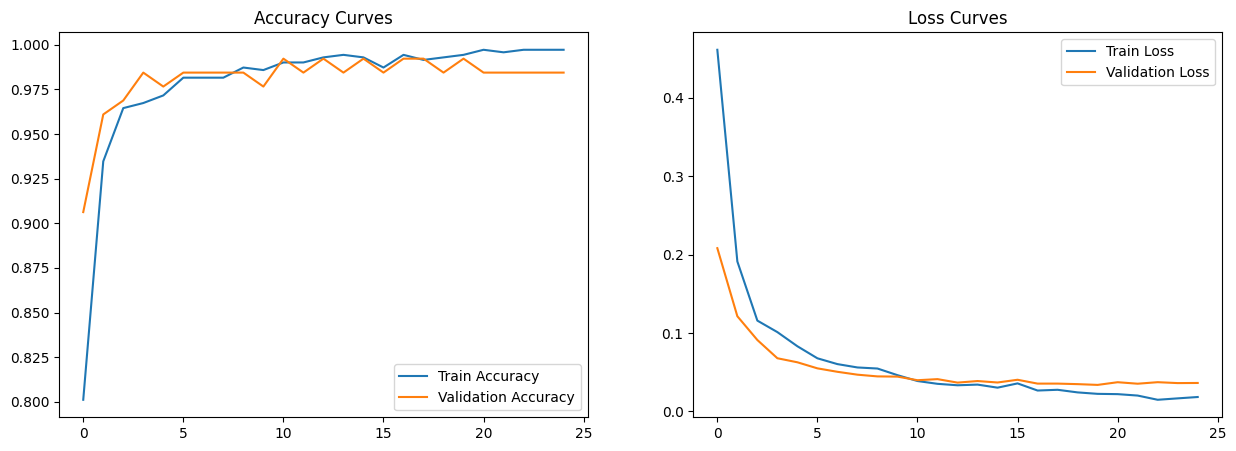

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step

--- Classification Report ---
                 precision    recall  f1-score   support

    fire_images       0.99      1.00      1.00       131
non_fire_images       1.00      0.97      0.99        36

       accuracy                           0.99       167
      macro avg       1.00      0.99      0.99       167
   weighted avg       0.99      0.99      0.99       167


--- Confusion Matrix ---


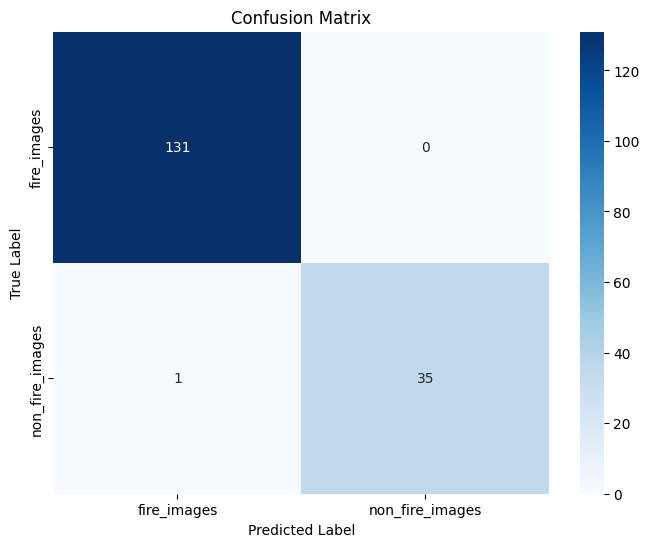

In [ ]:
# === Step 6: Evaluate and Display Results ===
print("\n6. Evaluating the model and displaying results...")

# 1. Final evaluation on the test set
print("\n--- Performance Evaluation on Test Data ---")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# 2. Plot performance curves
def plot_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    axes[0].plot(acc, label='Train Accuracy')
    axes[0].plot(val_acc, label='Validation Accuracy')
    axes[0].set_title('Accuracy Curves')
    axes[0].legend()

    axes[1].plot(loss, label='Train Loss')
    axes[1].plot(val_loss, label='Validation Loss')
    axes[1].set_title('Loss Curves')
    axes[1].legend()
    plt.show()

plot_history(history)

# 3. Classification report and confusion matrix
# Extract predictions and true labels from the test set
y_pred_probs = model.predict(test_ds)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true = np.argmax(y_true, axis=1)

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
# === Step 7: Save and download the model ===
print("\n7. Saving the final model...")
# Use the new recommended .keras extension
model.save('fire_detection_model_v2.keras')
files.download('fire_detection_model_v2.keras')

print("\nProcess finished successfully!")


7. Saving the final model...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Process finished successfully!
